Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("cvd_dataset.csv")

In [3]:
#Missing values and duplicates
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
display(pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).query("missing_count > 0"))

print("Duplicate rows:", df.duplicated().sum())

,missing_count,missing_pct
Diastolic BP,82,5.36
Weight (kg),81,5.30
HDL (mg/dL),80,5.23
Waist-to-Height Ratio,79,5.17
Age,78,5.10
Height (cm),74,4.84
Total Cholesterol (mg/dL),73,4.77
Systolic BP,71,4.64
CVD Risk Score,70,4.58
Estimated LDL (mg/dL),69,4.51


Duplicate rows: 0


In [4]:
#strip whitespaces in object columns
obj_cols = df.select_dtypes(include=["object", "string"]).columns
for c in obj_cols:
    df[c] = df[c].astype(str).str.strip()

In [11]:
#summary statistics of numeric variables
display(df[num_cols].describe().T)

#distribution of categorical variables
for col in cat_cols:
    print(f"\nValue counts for {col}:")
    display(df[col].value_counts())

,count,mean,std,min,25%,50%,75%,max
Age,1451.0,47.025500,12.421063,25.000,37.000,46.0000,55.00000,79.000
Weight (kg),1448.0,85.917427,21.012580,50.100,67.050,86.6145,105.00000,120.000
Height (m),1462.0,1.754111,0.113090,1.502,1.660,1.7550,1.84550,2.000
BMI,1465.0,28.465997,7.038685,15.000,22.629,28.1590,34.00000,46.200
Abdominal Circumference (cm),1462.0,91.773214,12.823573,70.000,80.500,91.6000,102.26900,119.996
Total Cholesterol (mg/dL),1456.0,198.539148,57.794099,100.000,150.000,197.0000,249.00000,300.000
HDL (mg/dL),1449.0,56.197378,16.066754,30.000,42.000,56.0000,70.00000,89.000
Fasting Blood Sugar (mg/dL),1462.0,117.485636,30.289174,70.000,92.000,115.0000,138.00000,198.000
Height (cm),1455.0,175.390600,11.251527,150.000,166.000,175.6940,184.20850,199.960
Waist-to-Height Ratio,1450.0,0.525727,0.081213,0.360,0.460,0.5220,0.58375,0.787



Value counts for Sex:


Sex
F    773
M    756
Name: count, dtype: int64


Value counts for Blood Pressure (mmHg):


Blood Pressure (mmHg)
114/63     4
127/84     4
113/79     4
113/77     4
120/89     3
          ..
175/80     1
105/87     1
162/60     1
102/115    1
150/90     1
Name: count, Length: 1254, dtype: int64

...

Family History of CVD
N    780
Y    749
Name: count, dtype: int64


Value counts for CVD Risk Level:


CVD Risk Level
HIGH            728
INTERMEDIARY    581
LOW             220
Name: count, dtype: int64


Value counts for Blood Pressure Category:


Blood Pressure Category
Hypertension Stage 2    632
Hypertension Stage 1    497
Normal                  300
Elevated                100
Name: count, dtype: int64

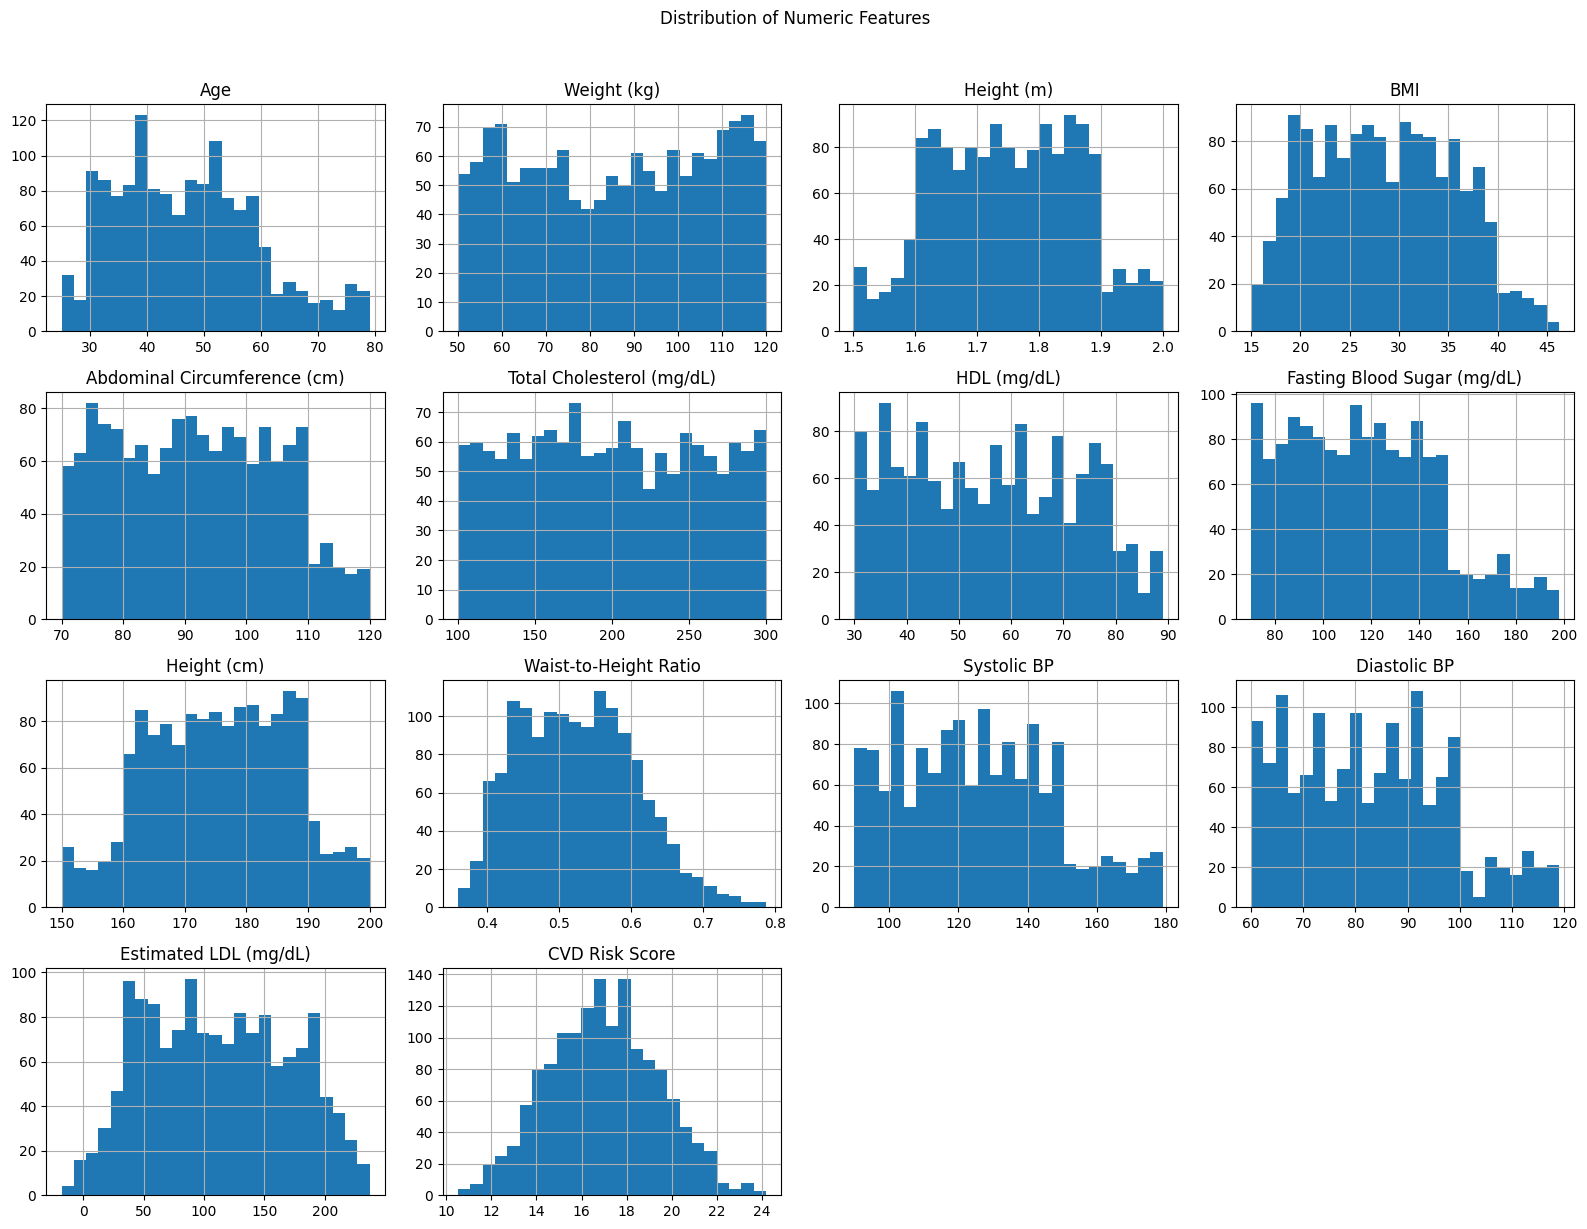

In [ ]:
# Univariate Plots of Input Features
# Histograms for numeric variables
df[num_cols].hist(bins=25, figsize=(16, 12))
plt.suptitle("Distribution of Numeric Features", y=1.02)
plt.tight_layout()
plt.show()


CVD Risk Level
HIGH            728
INTERMEDIARY    581
LOW             220
Name: count, dtype: int64

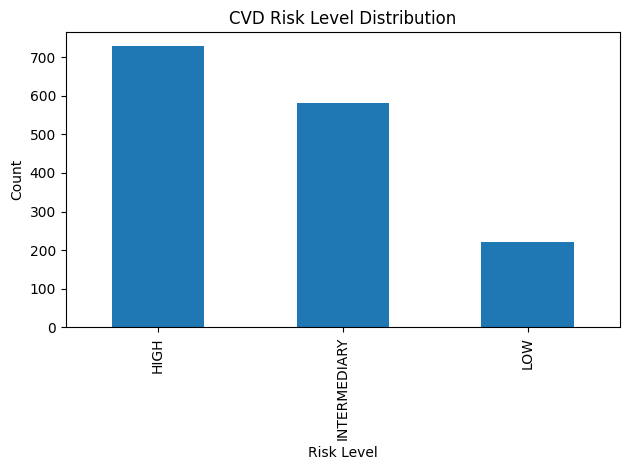

In [6]:
# examining classification balance (high, intermediary, low)
if "CVD Risk Level" in df.columns:
    risk_counts = df["CVD Risk Level"].value_counts()
    display(risk_counts)

    risk_counts.plot(kind="bar")
    plt.title("CVD Risk Level Distribution")
    plt.xlabel("Risk Level")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

CVD Risk Level,HIGH,INTERMEDIARY,LOW
Sex,,,
F,0.490298,0.372574,0.137128
M,0.461640,0.387566,0.150794


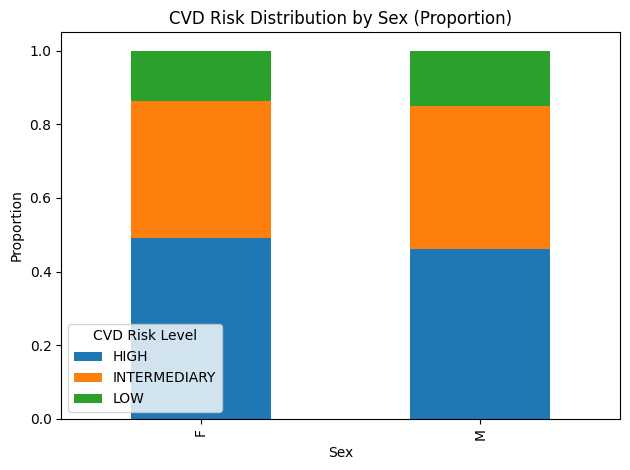

In [10]:
#CVD distribution compared by sex
if "Sex" in df.columns and "CVD Risk Level" in df.columns:
    gender_risk = pd.crosstab(df["Sex"], df["CVD Risk Level"], normalize="index")
    display(gender_risk)

    gender_risk.plot(kind="bar", stacked=True)
    plt.title("CVD Risk Distribution by Sex (Proportion)")
    plt.xlabel("Sex")
    plt.ylabel("Proportion")
    plt.tight_layout()
    plt.show()